# PLS: 5 Behavioral Parameters → Mental Health + Affect

Test whether the 5 params {k, z, β, α, ρ} jointly map onto mental health and affect dimensions.

**X block (behavioral):** k, z, β, α, ρ
**Y block (mental health + affect):** 3 psychiatric factors + mean anxiety + mean confidence + threat sensitivity of anxiety/confidence

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from sklearn.cross_decomposition import PLSCanonical, PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, KFold
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

ROOT = Path("../../")
DATA = ROOT / "data/exploratory_350/processed/stage5_filtered_data_20260317_094210"
RESULTS = ROOT / "results"
STAT_DIR = RESULTS / "stats"
FIG_DIR = RESULTS / "figs"

print("Setup complete")

Setup complete


## 1. Build X and Y matrices

In [2]:
# --- X block: 5 behavioral params ---
params = pd.read_csv(STAT_DIR / "vigor_hbm_posteriors.csv")
X_cols = ["k", "z", "beta", "alpha_bayes", "rho_bayes"]
X_labels = ["k", "z", "β", "α", "ρ"]

# --- Y block: psychiatric factors (compute fresh with 3 factors) ---
psych = pd.read_csv(DATA / "psych.csv")
efa_cols = [
    "DASS21_Stress", "DASS21_Anxiety", "DASS21_Depression",
    "AMI_Behavioural", "AMI_Social", "AMI_Emotional",
    "MFIS_Physical", "MFIS_Cognitive", "MFIS_Psychosocial",
    "OASIS_Total", "PHQ9_Total", "STICSA_Total",
    "STAI_State", "STAI_Trait",
]

from sklearn.decomposition import FactorAnalysis as FA

psych_valid = psych.dropna(subset=efa_cols)
X_psych = StandardScaler().fit_transform(psych_valid[efa_cols])

def varimax_rotation(L, max_iter=100, tol=1e-6):
    L = L.copy()
    p, k = L.shape
    rot = np.eye(k)
    for _ in range(max_iter):
        old = rot.copy()
        for i in range(k):
            for j in range(i+1, k):
                u = L[:, i]**2 - L[:, j]**2
                v = 2 * L[:, i] * L[:, j]
                num = 2*p*(u*v).sum() - 2*u.sum()*v.sum()
                den = p*((u**2 - v**2).sum()) - (u.sum()**2 - v.sum()**2)
                angle = 0.25 * np.arctan2(num, den)
                r = np.eye(k)
                r[i,i] = np.cos(angle); r[j,j] = np.cos(angle)
                r[i,j] = -np.sin(angle); r[j,i] = np.sin(angle)
                L = L @ r; rot = rot @ r
        if np.max(np.abs(rot - old)) < tol: break
    return L, rot

fa3 = FA(n_components=3, random_state=42)
fa3.fit(X_psych)
_, rot_mat = varimax_rotation(fa3.components_.T)
scores_3f = fa3.transform(X_psych) @ rot_mat
factor_df = pd.DataFrame(scores_3f, columns=["F1", "F2", "F3"],
                          index=psych_valid.index)
factor_df["subj"] = psych_valid["subj"].values

# --- Subject-level affect from probe ratings ---
feelings = pd.read_csv(DATA / "feelings.csv")
anx = feelings[feelings["questionLabel"] == "anxiety"]
conf = feelings[feelings["questionLabel"] == "confidence"]

anx_mean = anx.groupby("subj")["response"].mean().rename("anx_mean")
conf_mean = conf.groupby("subj")["response"].mean().rename("conf_mean")

def threat_slope(group):
    if group["threat"].std() == 0:
        return np.nan
    return np.corrcoef(group["threat"], group["response"])[0, 1]

anx_threat = anx.groupby("subj").apply(threat_slope).rename("anx_threat_sens")
conf_threat = conf.groupby("subj").apply(threat_slope).rename("conf_threat_sens")

affect = pd.concat([anx_mean, conf_mean, anx_threat, conf_threat], axis=1).reset_index()

# Merge everything
merged = params[["subj"] + X_cols].merge(factor_df, on="subj").merge(affect, on="subj")
merged = merged.dropna()
print(f"N = {len(merged)}")

Y_cols = ["F1", "F2", "F3", "anx_mean", "conf_mean", "anx_threat_sens", "conf_threat_sens"]
Y_labels = ["Distress", "Fatigue", "Apathy", "Mean Anxiety", "Mean Confidence",
            "Anx Threat Sens", "Conf Threat Sens"]

# Standardize
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X = scaler_x.fit_transform(merged[X_cols])
Y = scaler_y.fit_transform(merged[Y_cols])

print(f"X: {X.shape} ({len(X_cols)} params)")
print(f"Y: {Y.shape} ({len(Y_cols)} outcomes)")

N = 285
X: (285, 5) (5 params)
Y: (285, 7) (7 outcomes)


/opt/anaconda3/envs/effort_foraging_threat/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/effort_foraging_threat/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/anaconda3/envs/effort_foraging_threat/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/effort_foraging_threat/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 2. PLS Regression — determine number of components

In [3]:
# Cross-validated R² for 1-5 components
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_r2 = []

for n_comp in range(1, 6):
    pls = PLSRegression(n_components=n_comp, scale=False)
    Y_pred_cv = cross_val_predict(pls, X, Y, cv=kf)
    
    # Overall R²
    ss_res = ((Y - Y_pred_cv)**2).sum()
    ss_tot = ((Y - Y.mean(axis=0))**2).sum()
    r2_cv = 1 - ss_res / ss_tot
    
    # Per-Y R²
    r2_per_y = []
    for j in range(Y.shape[1]):
        ss_r = ((Y[:, j] - Y_pred_cv[:, j])**2).sum()
        ss_t = ((Y[:, j] - Y[:, j].mean())**2).sum()
        r2_per_y.append(1 - ss_r / ss_t)
    
    cv_r2.append({"n_comp": n_comp, "R2_cv_total": r2_cv,
                  **{Y_labels[j]: r2_per_y[j] for j in range(len(Y_labels))}})
    print(f"  {n_comp} comp: CV R²={r2_cv:.3f}  per-Y: {['%.3f'%r for r in r2_per_y]}")

cv_df = pd.DataFrame(cv_r2)
best_n = cv_df.loc[cv_df["R2_cv_total"].idxmax(), "n_comp"]
print(f"\nBest: {best_n} components (CV R²={cv_df['R2_cv_total'].max():.3f})")

  1 comp: CV R²=0.035  per-Y: ['-0.020', '-0.008', '0.072', '0.032', '-0.000', '0.116', '0.056']
  2 comp: CV R²=0.035  per-Y: ['-0.033', '-0.013', '0.088', '0.032', '-0.000', '0.116', '0.057']
  3 comp: CV R²=0.039  per-Y: ['-0.035', '-0.004', '0.101', '0.033', '0.009', '0.119', '0.048']
  4 comp: CV R²=0.038  per-Y: ['-0.041', '-0.006', '0.116', '0.031', '0.003', '0.124', '0.042']
  5 comp: CV R²=0.037  per-Y: ['-0.043', '-0.013', '0.119', '0.027', '0.000', '0.123', '0.044']

Best: 3 components (CV R²=0.039)


## 3. Fit PLS with best number of components

In [4]:
n_comp = max(int(best_n), 2)  # at least 2 for visualization
pls = PLSRegression(n_components=n_comp, scale=False)
pls.fit(X, Y)

# X and Y loadings (weights)
x_weights = pd.DataFrame(pls.x_weights_, index=X_labels,
                          columns=[f"Comp{i+1}" for i in range(n_comp)])
y_loadings = pd.DataFrame(pls.y_loadings_, index=Y_labels,
                           columns=[f"Comp{i+1}" for i in range(n_comp)])

print("=== X weights (behavioral params) ===")
print(x_weights.round(3))
print("\n=== Y loadings (mental health + affect) ===")
print(y_loadings.round(3))

# In-sample R² per Y
Y_pred = pls.predict(X)
print("\nIn-sample R² per Y variable:")
for j, label in enumerate(Y_labels):
    r2 = 1 - ((Y[:, j] - Y_pred[:, j])**2).sum() / ((Y[:, j] - Y[:, j].mean())**2).sum()
    print(f"  {label:20s}: R²={r2:.3f}")

=== X weights (behavioral params) ===
   Comp1  Comp2  Comp3
k -0.593  0.660 -0.134
z -0.015  0.486 -0.258
β  0.166  0.280  0.399
α  0.780  0.473 -0.077
ρ -0.104  0.160  0.866

=== Y loadings (mental health + affect) ===
                  Comp1  Comp2  Comp3
Distress         -0.062 -0.055  0.069
Fatigue          -0.043  0.085 -0.100
Apathy           -0.273 -0.184 -0.034
Mean Anxiety     -0.187  0.065  0.130
Mean Confidence   0.068 -0.190 -0.078
Anx Threat Sens   0.330 -0.043  0.100
Conf Threat Sens -0.240  0.014 -0.132

In-sample R² per Y variable:
  Distress            : R²=0.013
  Fatigue             : R²=0.020
  Apathy              : R²=0.130
  Mean Anxiety        : R²=0.065
  Mean Confidence     : R²=0.052
  Anx Threat Sens     : R²=0.145
  Conf Threat Sens    : R²=0.088


In [5]:
# Permutation test for significance
n_perm = 5000
rng = np.random.default_rng(42)

# Observed total R²
Y_pred_obs = pls.predict(X)
ss_res_obs = ((Y - Y_pred_obs)**2).sum()
ss_tot = ((Y - Y.mean(axis=0))**2).sum()
r2_obs = 1 - ss_res_obs / ss_tot

r2_perm = np.zeros(n_perm)
for i in range(n_perm):
    Y_shuf = Y[rng.permutation(len(Y))]
    pls_perm = PLSRegression(n_components=n_comp, scale=False)
    pls_perm.fit(X, Y_shuf)
    Y_pred_p = pls_perm.predict(X)
    ss_res_p = ((Y_shuf - Y_pred_p)**2).sum()
    r2_perm[i] = 1 - ss_res_p / ((Y_shuf - Y_shuf.mean(axis=0))**2).sum()

p_perm = (r2_perm >= r2_obs).mean()
print(f"Observed R² = {r2_obs:.4f}")
print(f"Permutation p = {p_perm:.4f} ({n_perm} permutations)")
print(f"95th pctile null R² = {np.percentile(r2_perm, 95):.4f}")

Observed R² = 0.0732
Permutation p = 0.0000 (5000 permutations)
95th pctile null R² = 0.0224


## 4. Visualization

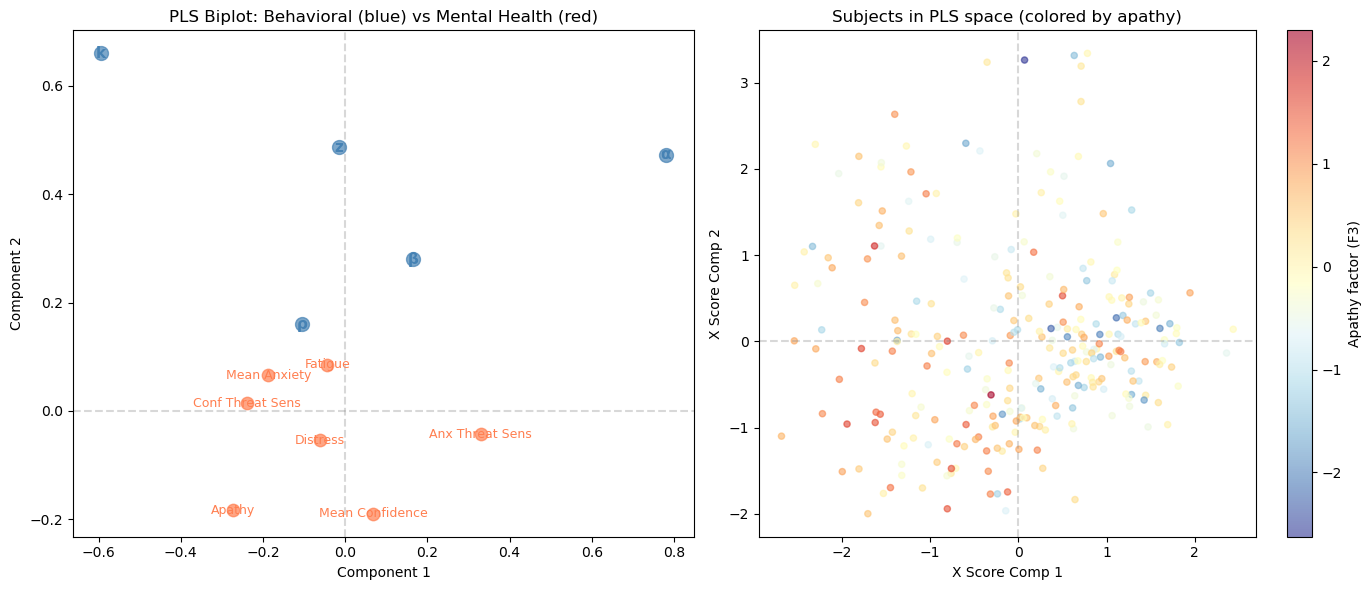

In [6]:
# Biplot: X and Y loadings on first 2 components
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Component 1 vs 2 loadings
ax = axes[0]
# X loadings (behavioral)
for i, label in enumerate(X_labels):
    ax.annotate(label, (x_weights.iloc[i, 0], x_weights.iloc[i, 1]),
                fontsize=11, fontweight="bold", color="steelblue",
                ha="center", va="center")
    ax.scatter(x_weights.iloc[i, 0], x_weights.iloc[i, 1],
              s=100, c="steelblue", alpha=0.7, zorder=5)

# Y loadings (mental health)
for i, label in enumerate(Y_labels):
    ax.annotate(label, (y_loadings.iloc[i, 0], y_loadings.iloc[i, 1]),
                fontsize=9, color="coral",
                ha="center", va="center")
    ax.scatter(y_loadings.iloc[i, 0], y_loadings.iloc[i, 1],
              s=80, c="coral", alpha=0.7, zorder=5)

ax.axhline(0, ls="--", color="gray", alpha=0.3)
ax.axvline(0, ls="--", color="gray", alpha=0.3)
ax.set(xlabel="Component 1", ylabel="Component 2",
       title="PLS Biplot: Behavioral (blue) vs Mental Health (red)")

# Score scatter colored by apathy factor
ax = axes[1]
T = pls.x_scores_  # X scores
apathy_z = merged["F3"].values
sc = ax.scatter(T[:, 0], T[:, 1], c=apathy_z, cmap="RdYlBu_r",
                s=20, alpha=0.6)
plt.colorbar(sc, ax=ax, label="Apathy factor (F3)")
ax.set(xlabel="X Score Comp 1", ylabel="X Score Comp 2",
       title="Subjects in PLS space (colored by apathy)")
ax.axhline(0, ls="--", color="gray", alpha=0.3)
ax.axvline(0, ls="--", color="gray", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "pls_params_mental_health.png", dpi=150, bbox_inches="tight")
plt.show()

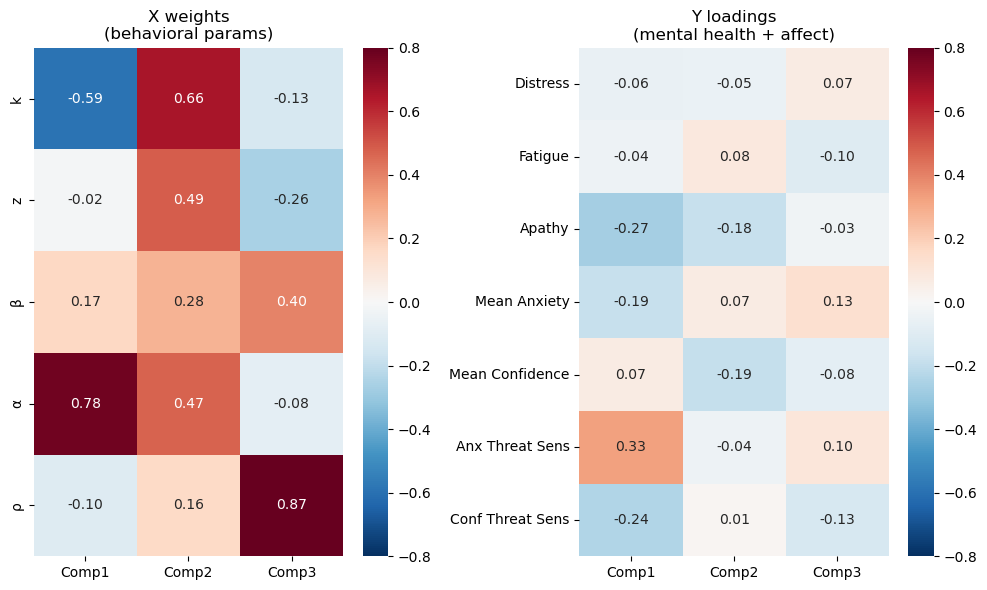

In [7]:
# Heatmap of X weights and Y loadings side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

sns.heatmap(x_weights, cmap="RdBu_r", vmin=-0.8, vmax=0.8,
            annot=True, fmt=".2f", ax=axes[0], annot_kws={"size": 10})
axes[0].set_title("X weights\n(behavioral params)")

sns.heatmap(y_loadings, cmap="RdBu_r", vmin=-0.8, vmax=0.8,
            annot=True, fmt=".2f", ax=axes[1], annot_kws={"size": 10})
axes[1].set_title("Y loadings\n(mental health + affect)")

plt.tight_layout()
plt.savefig(FIG_DIR / "pls_weights_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Component interpretation

In [8]:
# Correlations between X scores, Y scores, and original variables
T_x = pls.x_scores_
T_y = pls.y_scores_

print("=== X-Y score correlations (canonical correlations) ===")
for c in range(n_comp):
    r, p = stats.pearsonr(T_x[:, c], T_y[:, c])
    print(f"  Comp {c+1}: r={r:.3f}, p={p:.2e}")

print("\n=== Structure coefficients: corr(original vars, X scores) ===")
print("X variables:")
for c in range(n_comp):
    print(f"  Comp {c+1}:", end="")
    for i, label in enumerate(X_labels):
        r = np.corrcoef(X[:, i], T_x[:, c])[0, 1]
        print(f"  {label}={r:+.3f}", end="")
    print()

print("\nY variables:")
for c in range(n_comp):
    print(f"  Comp {c+1}:", end="")
    for j, label in enumerate(Y_labels):
        r = np.corrcoef(Y[:, j], T_x[:, c])[0, 1]
        sig = "*" if abs(r) > 0.15 else ""
        print(f"  {label[:8]}={r:+.3f}{sig}", end="")
    print()

=== X-Y score correlations (canonical correlations) ===
  Comp 1: r=0.538, p=8.44e-23
  Comp 2: r=0.300, p=2.52e-07
  Comp 3: r=0.228, p=1.03e-04

=== Structure coefficients: corr(original vars, X scores) ===
X variables:
  Comp 1:  k=-0.662  z=+0.019  β=+0.138  α=+0.851  ρ=-0.246
  Comp 2:  k=+0.638  z=+0.659  β=+0.432  α=+0.405  ρ=-0.010
  Comp 3:  k=-0.141  z=-0.250  β=+0.416  α=-0.085  ρ=+0.864

Y variables:
  Comp 1:  Distress=-0.069  Fatigue=-0.048  Apathy=-0.302*  Mean Anx=-0.207*  Mean Con=+0.075  Anx Thre=+0.364*  Conf Thr=-0.265*
  Comp 2:  Distress=-0.058  Fatigue=+0.089  Apathy=-0.194*  Mean Anx=+0.069  Mean Con=-0.200*  Anx Thre=-0.045  Conf Thr=+0.015
  Comp 3:  Distress=+0.069  Fatigue=-0.101  Apathy=-0.034  Mean Anx=+0.130  Mean Con=-0.078  Anx Thre=+0.100  Conf Thr=-0.133


## 6. Save

In [9]:
# Save results
x_weights.to_csv(STAT_DIR / "pls_mh_x_weights.csv")
y_loadings.to_csv(STAT_DIR / "pls_mh_y_loadings.csv")
cv_df.to_csv(STAT_DIR / "pls_mh_cv_results.csv", index=False)

print("Saved: pls_mh_x_weights.csv, pls_mh_y_loadings.csv, pls_mh_cv_results.csv")
print(f"\nSummary:")
print(f"  PLS with {n_comp} components")
print(f"  Observed R² = {r2_obs:.4f}, permutation p = {p_perm:.4f}")
print(f"  CV R² = {cv_df.loc[cv_df['n_comp']==n_comp, 'R2_cv_total'].values[0]:.4f}")

Saved: pls_mh_x_weights.csv, pls_mh_y_loadings.csv, pls_mh_cv_results.csv

Summary:
  PLS with 3 components
  Observed R² = 0.0732, permutation p = 0.0000
  CV R² = 0.0388
